<div style="text-align:center;font-size:28pt"> Visual Quality Checks</div>

This Notebook demonstrates the use of Visual QC [integrated in libinsitu](https://libinsitu.readthedocs.io/en/latest/api.html#visual-qc)

In [2]:
from gzip import GzipFile
from io import TextIOWrapper
%load_ext autoreload
%autoreload 2
%env LOGLEVEL=WARNING

# Not required if libinsitu is installed via `pip install libinsitu`
import sys
sys.path.append("..")

from libinsitu import  visual_qc, netcdf_to_dataframe
from datetime import datetime
from pvlib.iotools.midc import read_midc_raw_data_from_nrel
import pandas as pd

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: LOGLEVEL=WARNING


# 1) Requirements / input data

[`visual_qc()`](https://libinsitu.readthedocs.io/en/latest/api.html#visual-qc) takes a [Pandas dataframe](https://pandas.pydata.org/docs/user_guide/10min.html) as input, indexed by time, with 3 columns names :
* **GHI**
* **DHI**
* **BNI**

The time index should either contain **timezone information**, or **be in UTC**.

It also requires at least the following metadata :
* **latitude**
* **longitude**
* **altitude**

This metadata can be either attached to the attributes of the Dataframe (`.attrs`), or provided in the function call as parameters.

# 2) Get the data

You can build such a Dataframe in different ways.

To test an alternative, run the code in the corresponding **2.X)** section and then jump directly to section **3)**

## 2.1) Alternative 1 : Get data with pvlib

[pvlib](https://github.com/pvlib/pvlib-python) offers many functions to get data from various providers.

Here, we use the handler for **NREL / MIDC** to get 5 months of data for the station **UAT**

In [59]:
# 5 months of data of station UAT (may take several minutes)
df = read_midc_raw_data_from_nrel(
    "UAT",
    datetime(2011, 1, 1),
    datetime(2011, 5, 30))

In [62]:
# Pick and rename columns for the 3 components
df.rename(inplace=True,
    columns={
        "Direct Normal [W/m^2]": "BNI",
        "Diffuse Horiz [W/m^2]" : "DHI",
        "Global Horiz (tracker) [W/m^2]" : "GHI"})

# Remove other columns
df = df[["BNI", "GHI", "DHI"]]

# Filter large negative values
df = df.mask(df < -100)

In [61]:
# Metadata of the station, to be provided later to the QC function
latitude = 32.22969
longitude = -110.95534
elevation = 786
station_name = "UAT"

## 2.2) Alternative 2 : parse your own CSV file

You can parse / transform any CSV file to a Dataframe.
Here, we provide an example CSV file of one year of data from BMs station (NREL / MIDC network)

Look at the documentation of [pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) for more details.

In [3]:
# The following CSV contains one year of data from BMS station (NREL MIDC)
# let's first decompress it
!gunzip -k -f data/sample-data.csv.gz

# Let's use the 'head' system command line to look at it
!head -5 data/sample-data.csv

date,time,direct,temp,global,diffuse
2020-01-01,00:00:00,,,,
2020-01-01,00:01:00,,,,
2020-01-01,00:02:00,,,,
2020-01-01,00:03:00,,,,


In [4]:
# For more details on this function, check : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html
df = pd.read_csv(
    "data/sample-data.csv", # Input filename
    usecols=["date", "time", "global", "diffuse", "direct"], # Only get the columns we need (drop temp)
    parse_dates = [["date", "time"]], # We can combine several columns to build timestamp
    index_col = "date_time") # Use the parsed date time as index

# Rename columns
df.rename(inplace=True, columns={"global":"GHI", "diffuse":"DHI", "direct":"BNI"})

In [5]:
# Metadata of the station
latitude = 39.742
longitude = -105.18
elevation = 1828.8
station_name = "BMS"

## 2.3) Alternative 3 : get data from NetCDF, with libinsitu

Here, we fetch NetCDF data from our TDS server, over the OpenDAP protocol.

In [72]:
# One year of data from BMS (NREL_MIDC)
df = netcdf_to_dataframe(
    "http://tds.webservice-energy.org/thredds/dodsC/nrelmidc-stations/NREL_MIDC-BMS.nc",
    start_time=datetime(2020, 1, 1),
    end_time=datetime(2021, 1, 1),
    vars=["GHI", "BNI", "DHI"])

In [76]:
# The required metadata is directly attached to the dataframe
# We don't need to pass it to the function in section 3)
print("Latitude:", df.attrs["latitude"])
print("Longitude:", df.attrs["longitude"])
print("Elevation:", df.attrs["elevation"])

Latitude: 39.742
Longitude: -105.18
Elevation: 1828.8


# 3) Call visual_qc()

Now, we pass or Dataframe and metadata to `visual_qc`

See the [doc of visual_qc](https://libinsitu.readthedocs.io/en/latest/api.html#visual-qc) for more details.

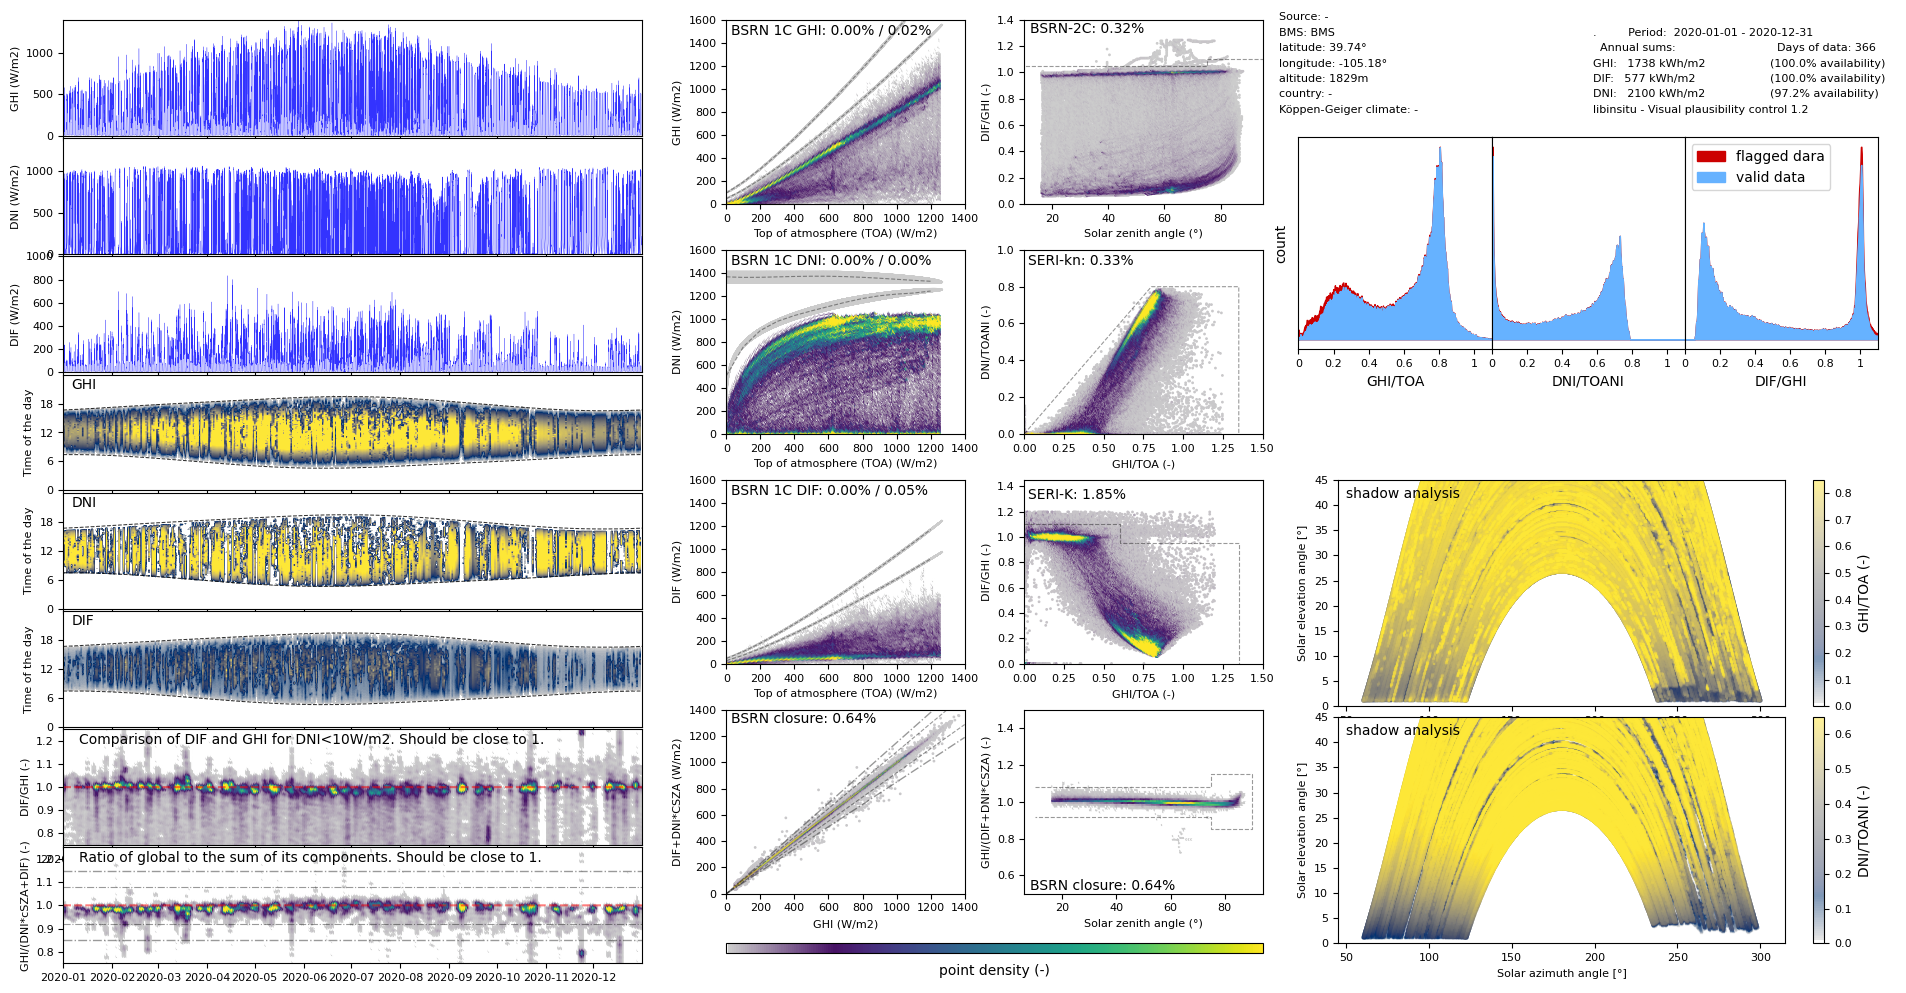

In [7]:
visual_qc(
    df, # The dataframe itself
    latitude=latitude,   # \
    longitude=longitude, #  } Can be obtained from metadata attached to the dataframe (see 2.3)
    elevation=elevation, # /
    station_id = station_name, station_name=station_name) # Optional